# Analise inicial da base de intoxicacao exogena em idosos

Este notebook considera apenas o periodo de `2007` a `2025`, descarta o registro de `1991` e completa anos ausentes com `0` notificacoes por estado e sexo.

## Imports

In [20]:
import sys
from pathlib import Path

from IPython.display import Image, Markdown, display

try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "Instale pandas, matplotlib e seaborn antes de executar este notebook. "
        "Exemplo no Jupyter: %pip install pandas matplotlib seaborn"
    ) from exc

cwd = Path.cwd().resolve()
if (cwd / "utils").exists():
    ROOT = cwd
elif (cwd.parent / "utils").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:,.2f}".format

## Methods

In [21]:
import importlib

from utils import intoxicacao_analysis as intox_analysis

intox_analysis = importlib.reload(intox_analysis)

DEFAULT_END_YEAR = intox_analysis.DEFAULT_END_YEAR
DEFAULT_SEX_PALETTE = intox_analysis.DEFAULT_SEX_PALETTE
DEFAULT_START_YEAR = intox_analysis.DEFAULT_START_YEAR
build_descriptive_stats = intox_analysis.build_descriptive_stats
build_insight_lines = intox_analysis.build_insight_lines
build_overall_by_year = intox_analysis.build_overall_by_year
build_state_case_totals = intox_analysis.build_state_case_totals
build_state_summary = intox_analysis.build_state_summary
build_state_year = intox_analysis.build_state_year
build_top_groups_by_state = intox_analysis.build_top_groups_by_state
build_toxic_profile = intox_analysis.build_toxic_profile
build_year_totals = intox_analysis.build_year_totals
filter_year_window = intox_analysis.filter_year_window
format_insights_markdown = intox_analysis.format_insights_markdown
load_intoxicacao_tidy = intox_analysis.load_intoxicacao_tidy
save_state_share_pie_charts = intox_analysis.save_state_share_pie_charts
save_state_sex_timeseries_charts = intox_analysis.save_state_sex_timeseries_charts
summarize_year_coverage = intox_analysis.summarize_year_coverage
write_text_report = intox_analysis.write_text_report

## Params

In [22]:
DATA_PATH = ROOT / "data" / "raw" / "Dados CFF - Intoxicação exógena .xlsx"
START_YEAR = DEFAULT_START_YEAR
END_YEAR = DEFAULT_END_YEAR
SEX_PALETTE = DEFAULT_SEX_PALETTE.copy()
SEX_HUE_ORDER = ["Masculino", "Feminino"]
TOP_N_TOXIC_GROUPS = 8
TOP_N_GROUPS_BY_STATE = 3
ASSETS_DIR = ROOT / "notebooks" / "assets"
OUTPUT_PATH = ROOT / "notebooks" / "outputs" / "insights_iniciais_intoxicacao.md"

params = pd.Series(
    {
        "data_path": str(DATA_PATH),
        "start_year": START_YEAR,
        "end_year": END_YEAR,
        "sex_palette": SEX_PALETTE,
        "top_n_toxic_groups": TOP_N_TOXIC_GROUPS,
        "top_n_groups_by_state": TOP_N_GROUPS_BY_STATE,
        "assets_dir": str(ASSETS_DIR),
        "output_path": str(OUTPUT_PATH),
    },
    name="value",
)
display(params.to_frame())

,value
data_path,/Users/manuelfjr/Documents/projects/hayse/tox-...
start_year,2007
end_year,2025
sex_palette,"{'Masculino': '#5B7FA3', 'Feminino': '#C06A6A'}"
top_n_toxic_groups,8
top_n_groups_by_state,3
assets_dir,/Users/manuelfjr/Documents/projects/hayse/tox-...
output_path,/Users/manuelfjr/Documents/projects/hayse/tox-...


## Read

In [23]:
df_raw = load_intoxicacao_tidy(DATA_PATH)

display(df_raw.head())
print(f"Linhas observadas na planilha: {len(df_raw):,}")
print(f"UFs presentes: {df_raw['state'].nunique()}")
print(f"Anos observados antes do filtro: {df_raw['year'].min()} a {df_raw['year'].max()}")

,state_code,state,sex,sex_label,year,toxic_group,count,total_year
0,AC,Acre,F,Feminino,2015,Ign/Branco,0.00,1.00
1,AC,Acre,F,Feminino,2015,Medicamento,1.00,1.00
2,AC,Acre,F,Feminino,2015,Outro,0.00,1.00
3,AC,Acre,F,Feminino,2015,Raticida,0.00,1.00
4,AC,Acre,F,Feminino,2019,Ign/Branco,1.00,1.00


Linhas observadas na planilha: 1,818
UFs presentes: 5
Anos observados antes do filtro: 1991 a 2025


## Processing

In [24]:
df = filter_year_window(df_raw, START_YEAR, END_YEAR)
coverage = summarize_year_coverage(df, START_YEAR, END_YEAR)
year_totals = build_year_totals(df, START_YEAR, END_YEAR)
state_summary = build_state_summary(year_totals)
descriptive_stats = build_descriptive_stats(year_totals)
overall_by_year = build_overall_by_year(year_totals)
state_case_totals = build_state_case_totals(year_totals)
state_year = build_state_year(year_totals)
toxic_profile = build_toxic_profile(df)
top_toxic = toxic_profile.groupby("sex_label").head(TOP_N_TOXIC_GROUPS).copy()
top_toxic["share_within_sex"] = (top_toxic["share_within_sex"] * 100).round(1)
top_group_by_state = build_top_groups_by_state(df, top_n=TOP_N_GROUPS_BY_STATE)

print(f"Linhas apos filtro {START_YEAR}-{END_YEAR}: {len(df):,}")
print(f"Combinacoes estado/sexo/ano na serie completa: {len(year_totals):,}")
print(f"Intervalo final da serie: {year_totals['year'].min()} a {year_totals['year'].max()}")

display(coverage)
display(state_summary)
display(descriptive_stats.round(2))
display(state_case_totals)
display(top_toxic)
display(top_group_by_state)

Linhas apos filtro 2007-2025: 1,804
Combinacoes estado/sexo/ano na serie completa: 190
Intervalo final da serie: 2007 a 2025


,state,state_code,sex_label,observed_years,filled_zero_years,missing_year_list
0,Acre,AC,Masculino,5,14,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014..."
1,Acre,AC,Feminino,7,12,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014..."
2,Distrito Federal,DF,Feminino,15,4,"2007, 2008, 2009, 2010"
3,Distrito Federal,DF,Masculino,15,4,"2007, 2008, 2009, 2010"
4,Paraiba,PB,Feminino,15,4,"2007, 2008, 2010, 2011"
5,Paraiba,PB,Masculino,16,3,"2007, 2009, 2010"
6,Santa Catarina,SC,Feminino,19,0,-
7,Santa Catarina,SC,Masculino,19,0,-
8,Sao Paulo,SP,Feminino,19,0,-
9,Sao Paulo,SP,Masculino,19,0,-


sex_label,Feminino,Masculino,Total,Percentual feminino
state,,,,
Sao Paulo,"4,891.00","2,686.00","7,577.00",64.60
Santa Catarina,"1,262.00",620.00,"1,882.00",67.10
Distrito Federal,309.00,183.00,492.00,62.80
Paraiba,222.00,201.00,423.00,52.50
Acre,20.00,6.00,26.00,76.90


,state,sex_label,years_in_series,non_zero_years,total_cases,mean_cases,median_cases,min_cases,max_cases,std_cases
0,Sao Paulo,Feminino,19,19,"4,891.00",257.42,184.00,28.00,686.00,201.53
1,Sao Paulo,Masculino,19,19,"2,686.00",141.37,129.00,28.00,314.00,89.56
2,Santa Catarina,Feminino,19,19,"1,262.00",66.42,49.00,7.00,171.00,51.56
3,Santa Catarina,Masculino,19,19,620.00,32.63,32.00,5.00,69.00,20.86
4,Distrito Federal,Feminino,19,15,309.00,16.26,9.00,0.00,53.00,17.08
5,Paraiba,Feminino,19,15,222.00,11.68,11.00,0.00,37.00,11.49
6,Paraiba,Masculino,19,16,201.00,10.58,8.00,0.00,37.00,9.67
7,Distrito Federal,Masculino,19,15,183.00,9.63,7.00,0.00,27.00,9.32
8,Acre,Feminino,19,7,20.00,1.05,0.00,0.00,9.00,2.17
9,Acre,Masculino,19,5,6.00,0.32,0.00,0.00,2.00,0.58


,sex_label,toxic_group,count,share_within_sex
0,Feminino,Medicamento,"5,304.00",79.10
1,Feminino,Raticida,393.00,5.90
2,Feminino,Ign/Branco,309.00,4.60
3,Feminino,Prod. uso domiciliar,177.00,2.60
4,Feminino,Outro,133.00,2.00
5,Feminino,Agrotóxico uso agrícola,100.00,1.50
6,Feminino,Agrotóxico uso doméstico,82.00,1.20
7,Feminino,Prod. químico uso industrial,70.00,1.00
15,Masculino,Medicamento,"1,905.00",51.50
16,Masculino,Raticida,662.00,17.90


,state,sex_label,toxic_group,count,share_within_state_sex
0,Acre,Feminino,Medicamento,17.00,85.00
1,Acre,Feminino,Ign/Branco,1.00,5.00
2,Acre,Feminino,Outro,1.00,5.00
3,Acre,Masculino,Ign/Branco,2.00,33.30
4,Acre,Masculino,Medicamento,2.00,33.30
5,Acre,Masculino,Agrotóxico uso doméstico,1.00,16.70
6,Distrito Federal,Feminino,Medicamento,244.00,79.00
7,Distrito Federal,Feminino,Ign/Branco,30.00,9.70
8,Distrito Federal,Feminino,Raticida,16.00,5.20
9,Distrito Federal,Masculino,Medicamento,101.00,55.20


## Graphs

In [33]:
(heatmap_data.T / heatmap_data.sum(axis=1)).T

year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,
Acre,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.08,0.04,0.12,0.08,0.42,0.08,0.15
Distrito Federal,0.00,0.00,0.00,0.00,0.00,0.01,0.05,0.02,0.02,0.02,0.04,0.06,0.08,0.07,0.08,0.13,0.14,0.12,0.16
Paraiba,0.00,0.00,0.00,0.00,0.00,0.04,0.02,0.04,0.04,0.03,0.05,0.07,0.07,0.04,0.07,0.09,0.12,0.13,0.17
Santa Catarina,0.01,0.01,0.01,0.01,0.02,0.02,0.02,0.03,0.04,0.04,0.06,0.06,0.07,0.07,0.07,0.09,0.12,0.10,0.12
Sao Paulo,0.01,0.01,0.01,0.01,0.02,0.02,0.03,0.04,0.04,0.04,0.05,0.06,0.07,0.06,0.07,0.09,0.12,0.11,0.13


,state,asset_path
0,Acre,notebooks/assets/trajetoria_anual_ac_acre.png
1,Distrito Federal,notebooks/assets/trajetoria_anual_df_distrito_...
2,Paraiba,notebooks/assets/trajetoria_anual_pb_paraiba.png
3,Santa Catarina,notebooks/assets/trajetoria_anual_sc_santa_cat...
4,Sao Paulo,notebooks/assets/trajetoria_anual_sp_sao_paulo...


### Acre

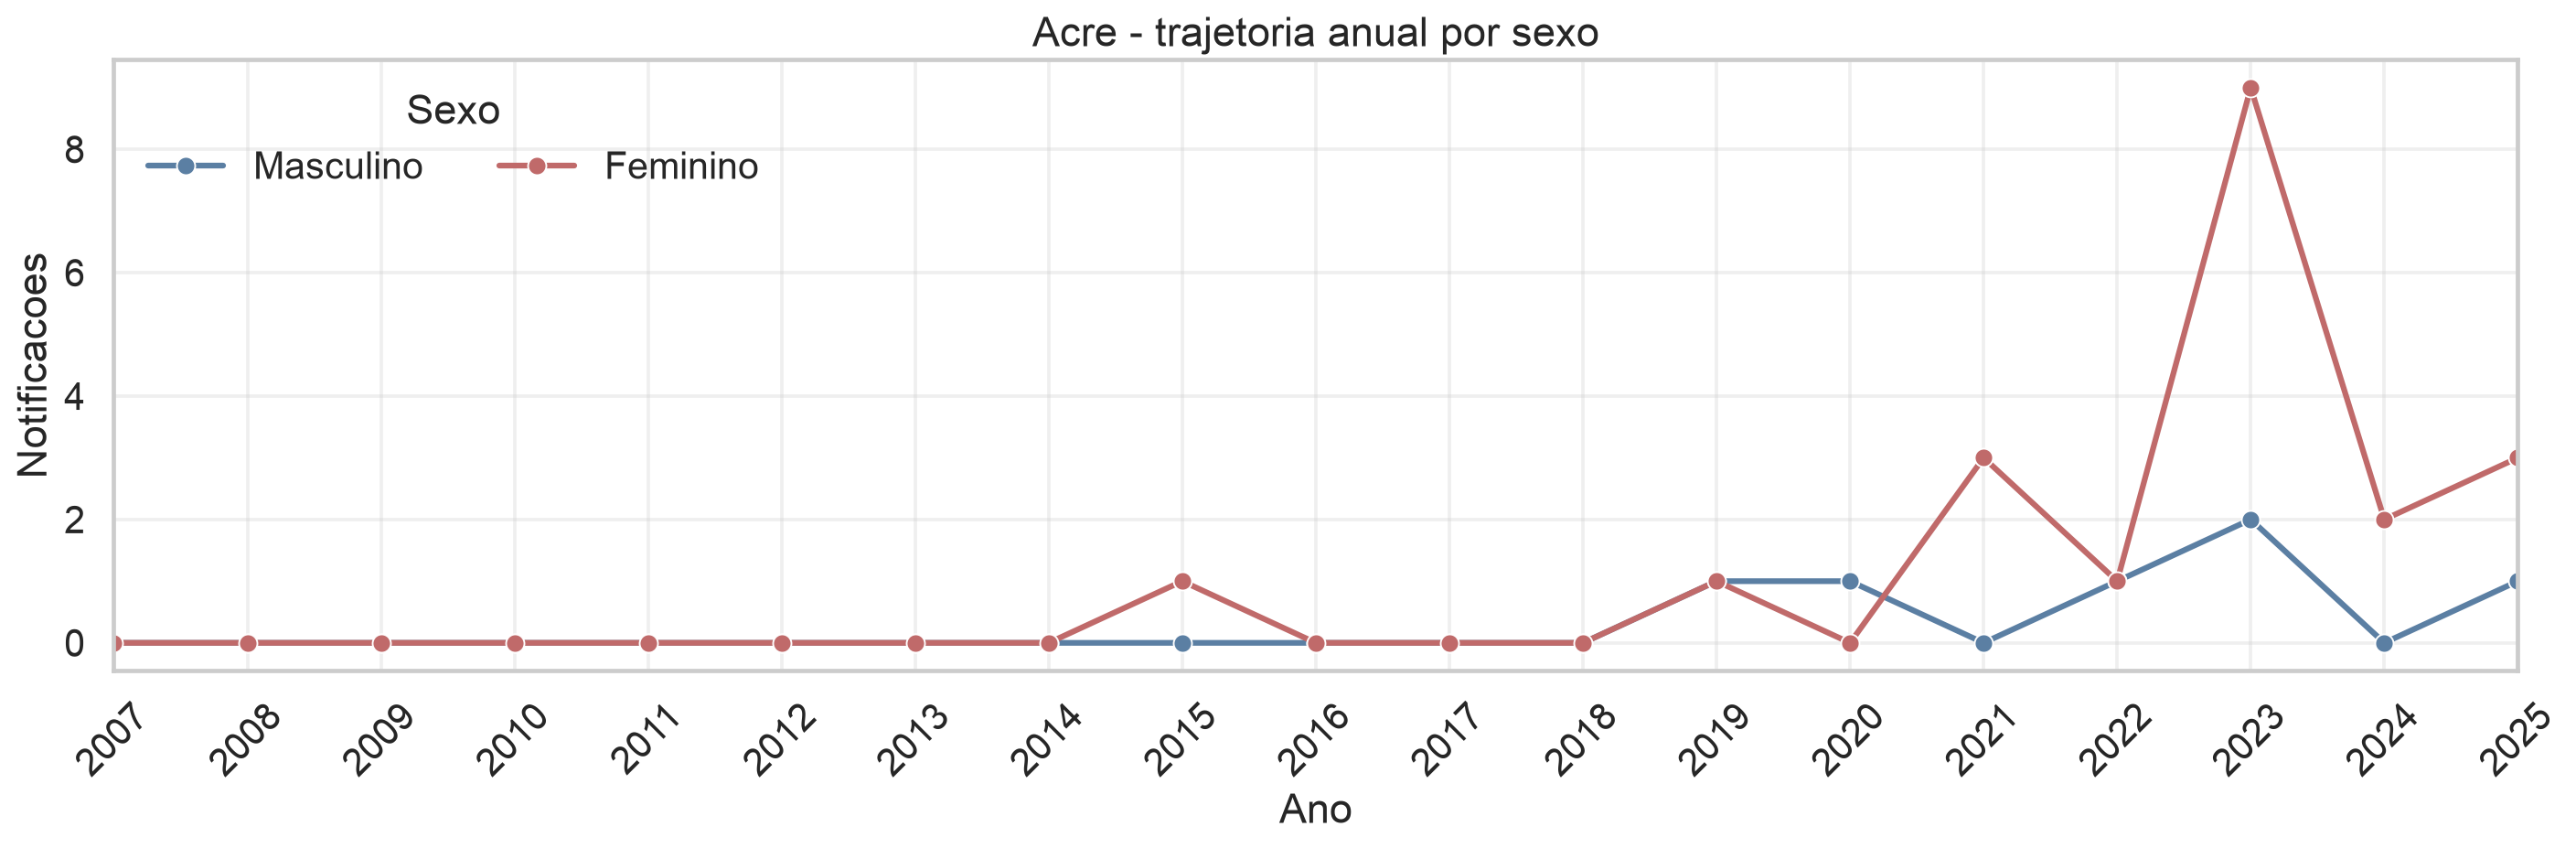

### Distrito Federal

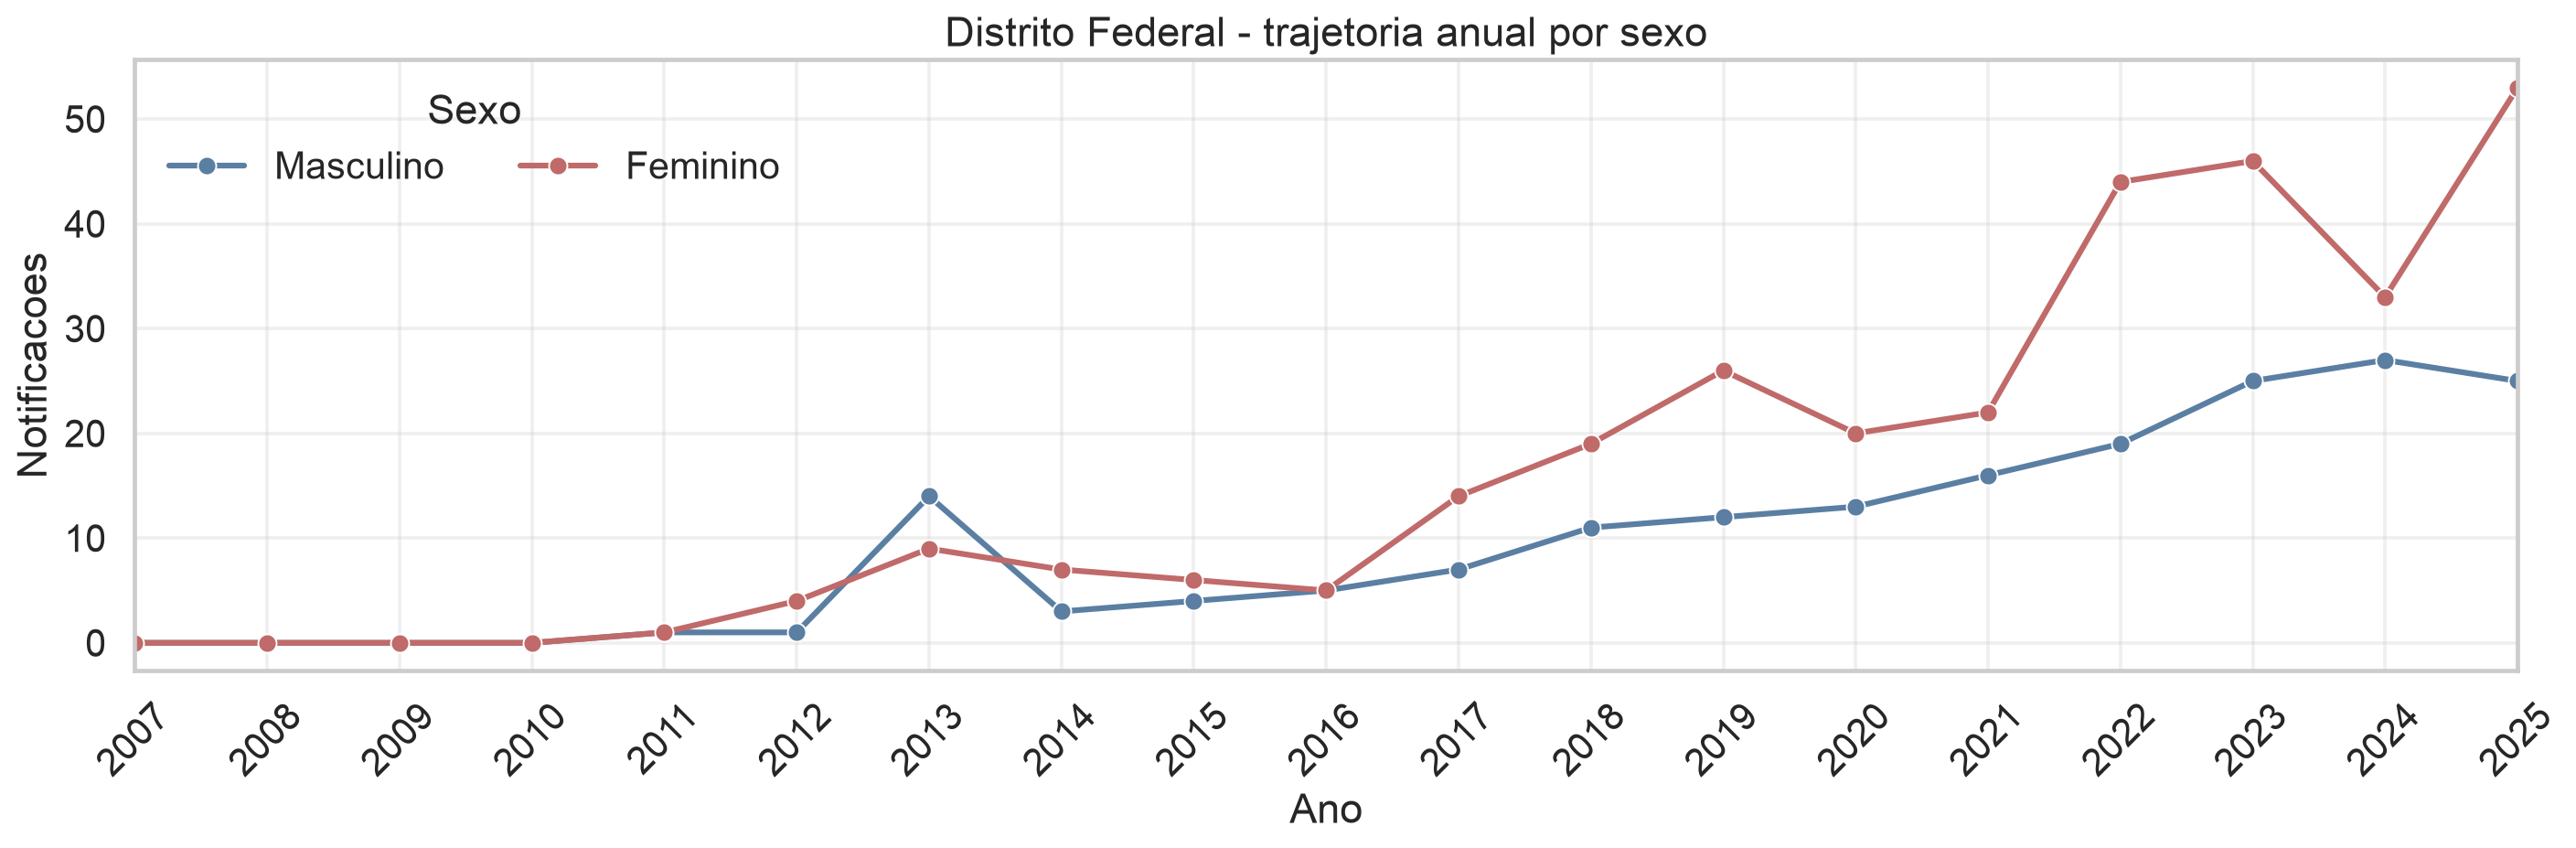

### Paraiba

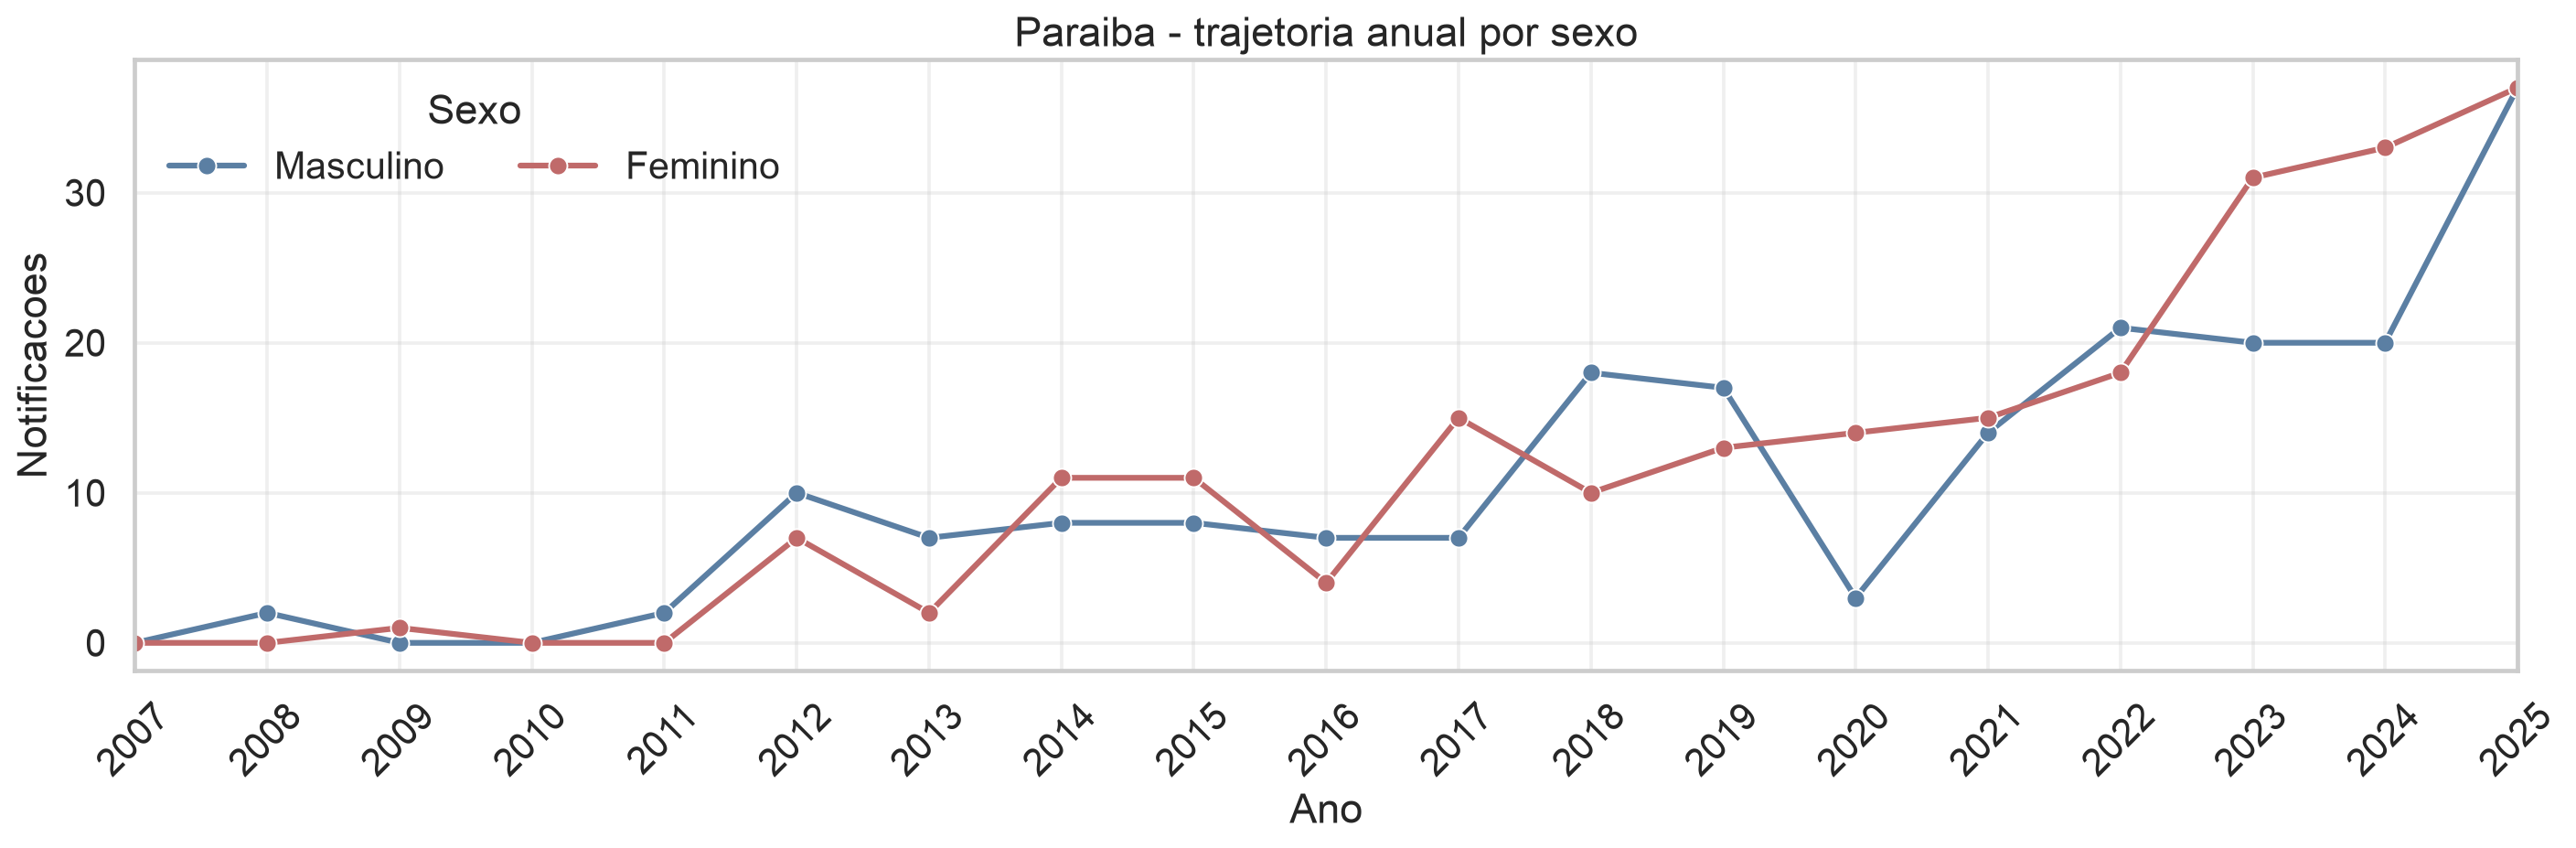

### Santa Catarina

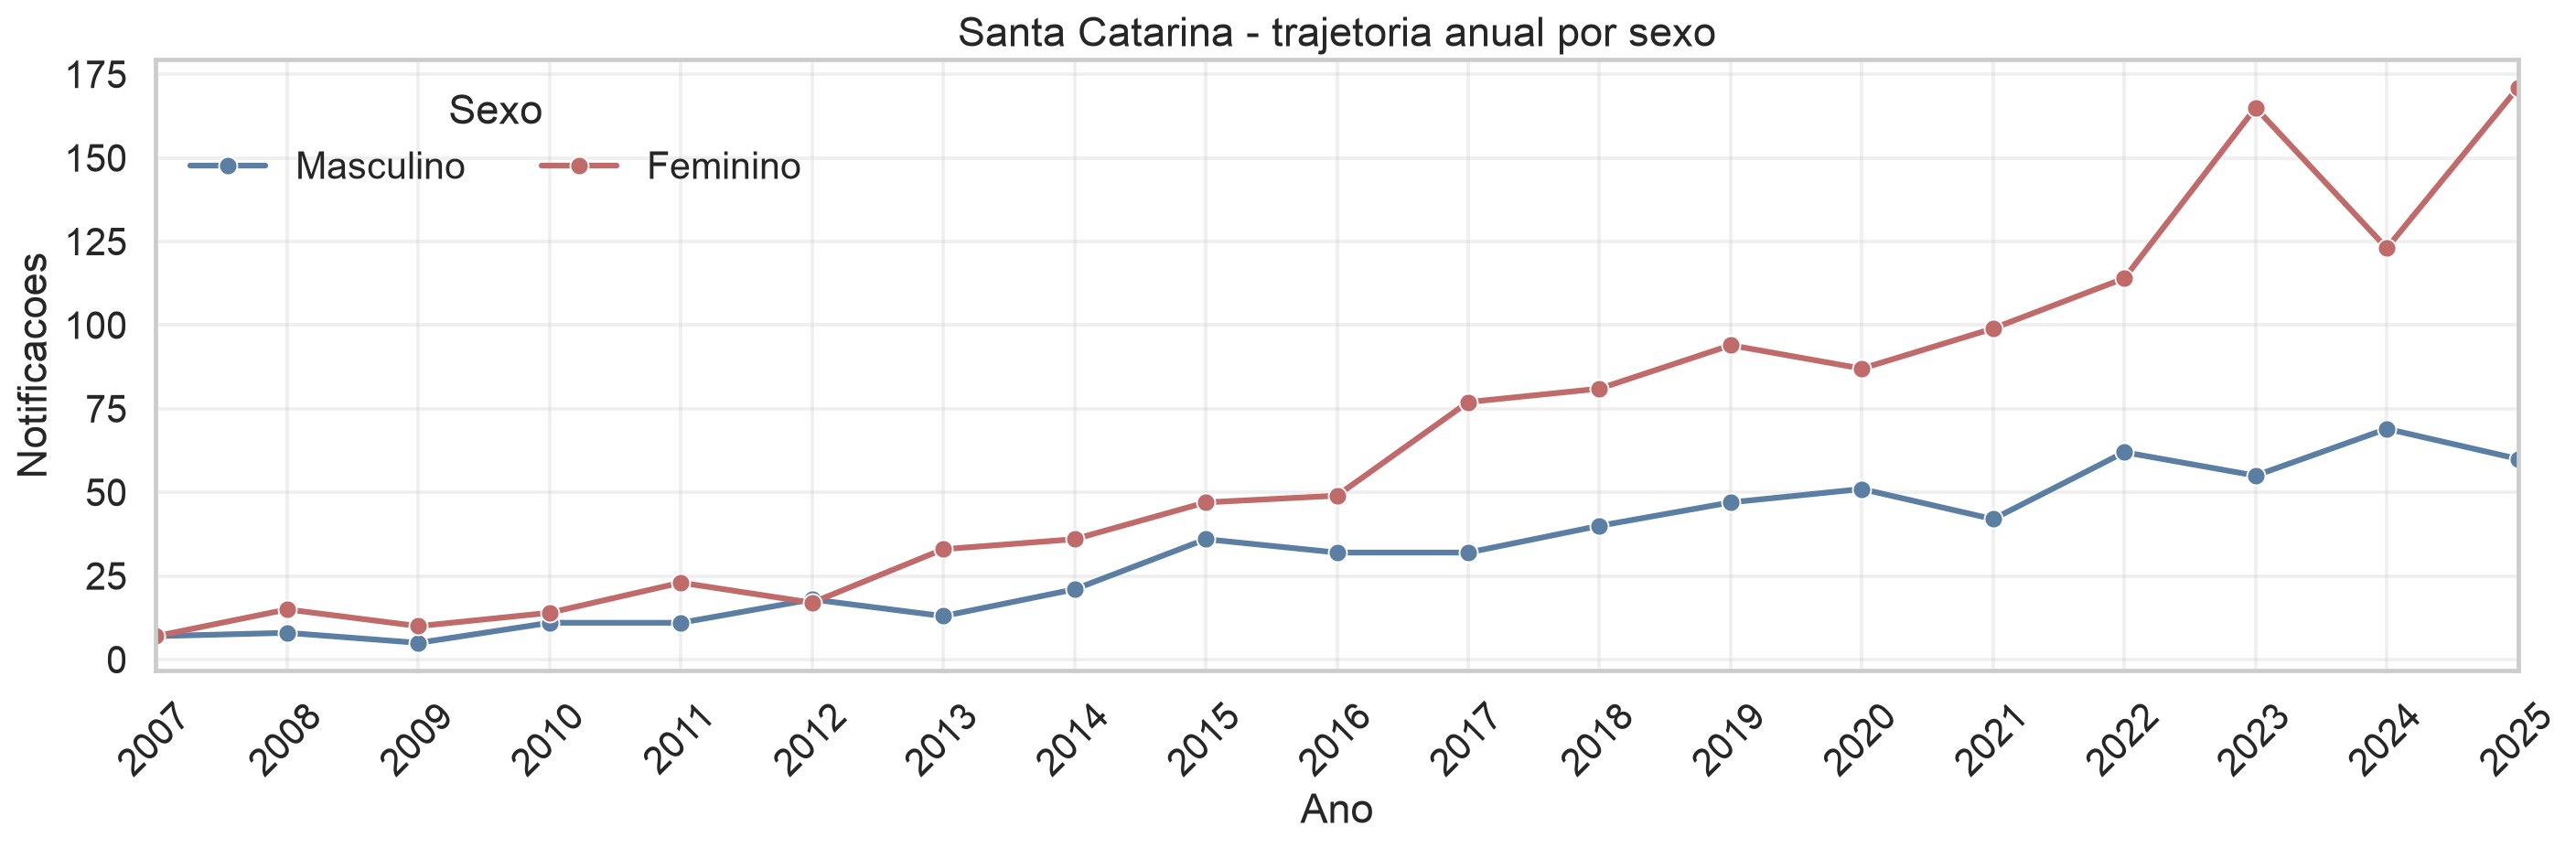

### Sao Paulo

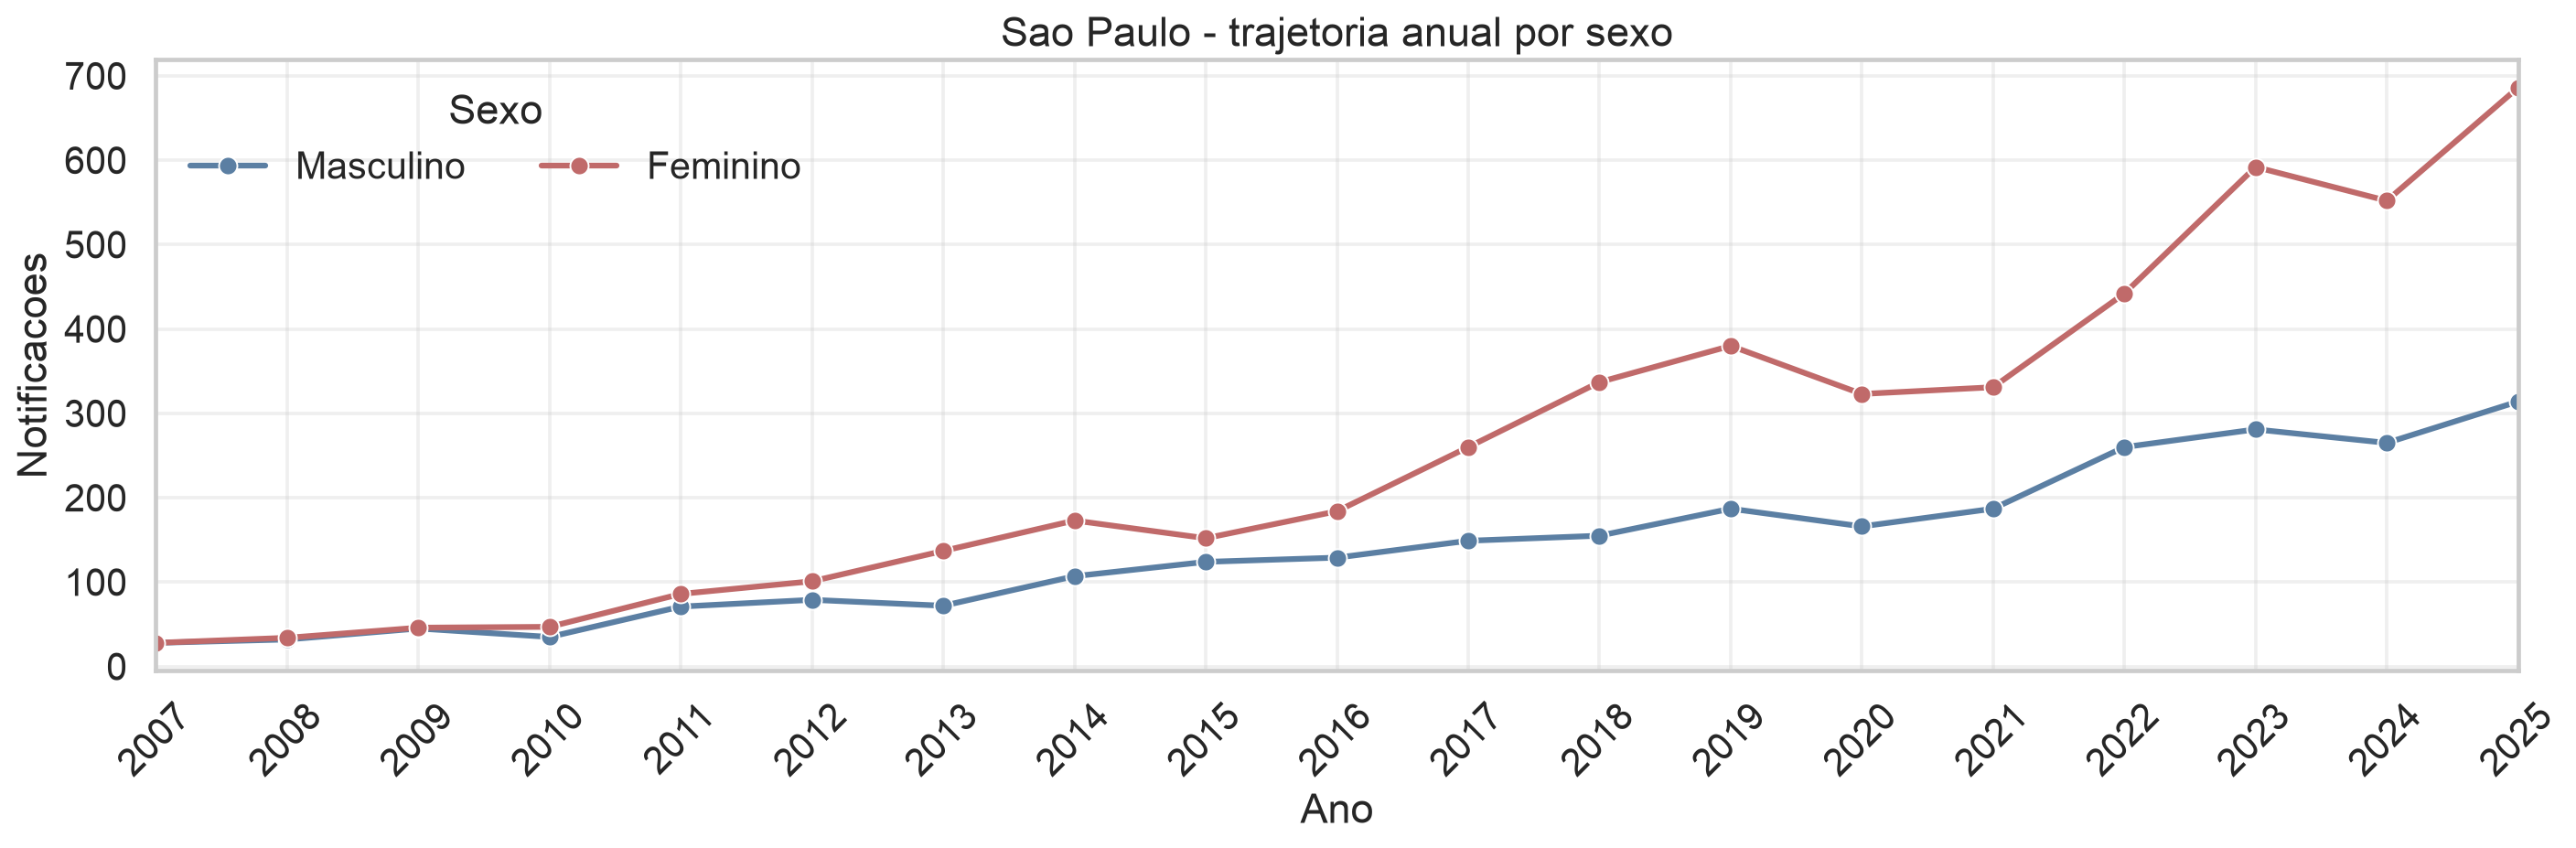

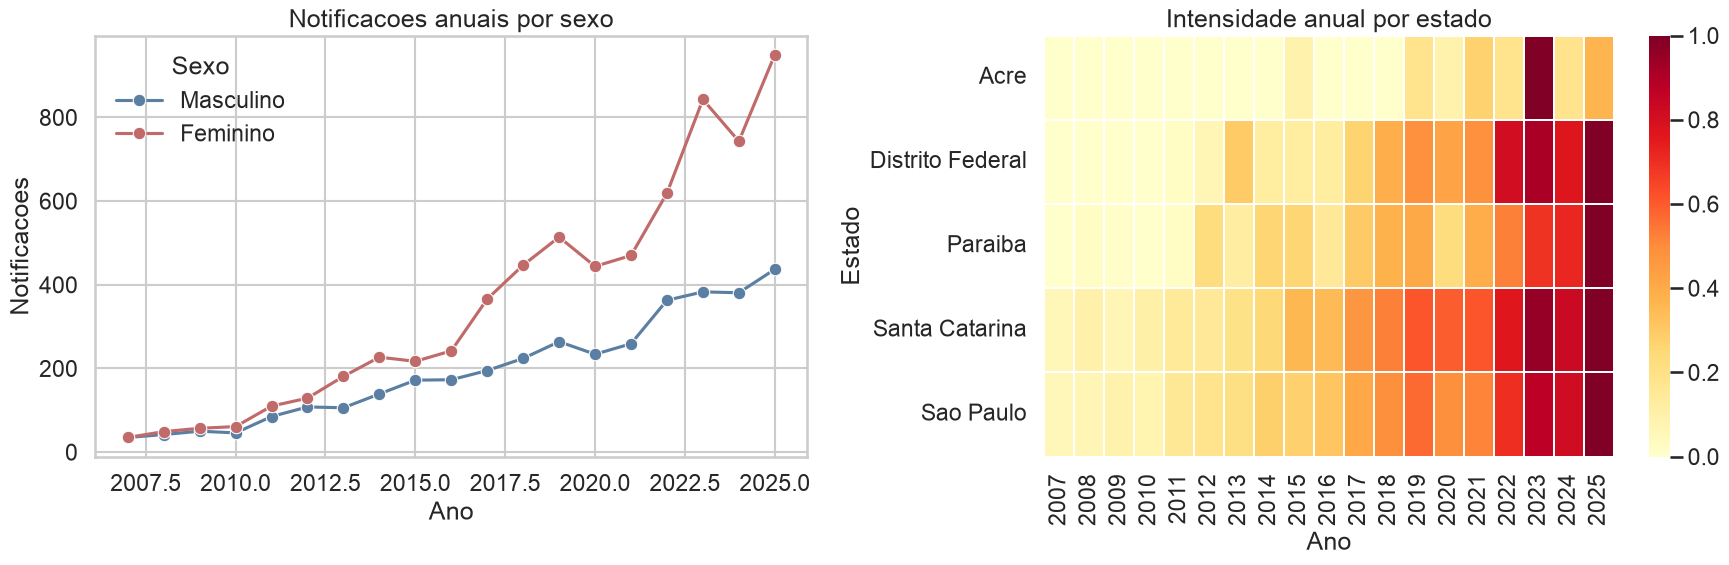

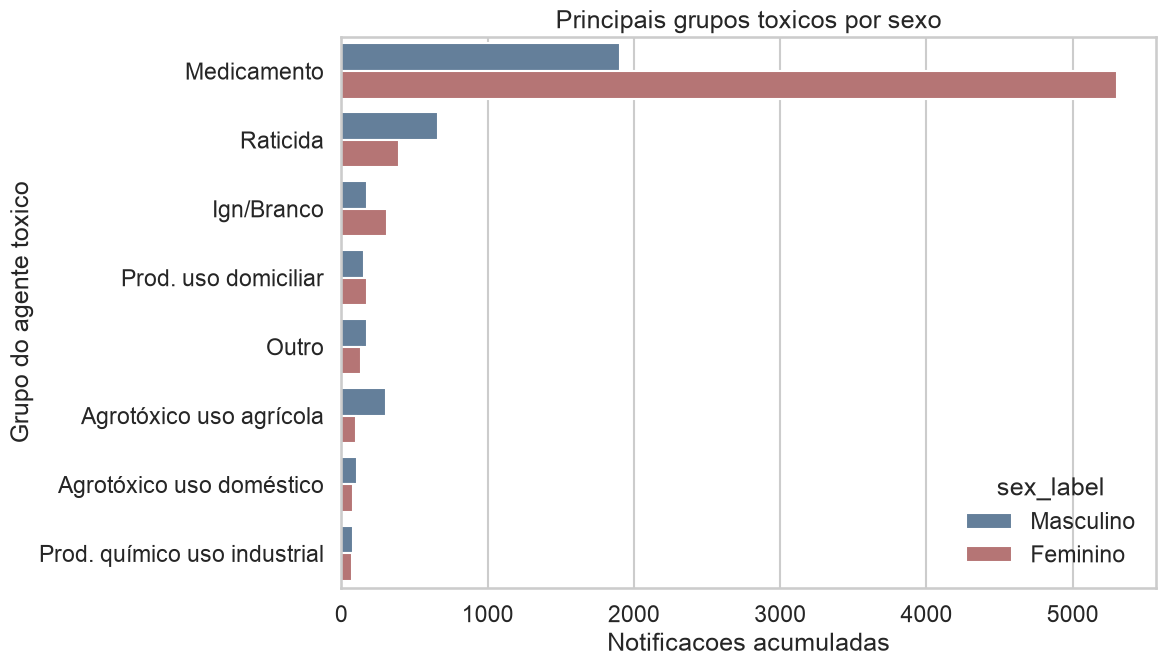

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=overall_by_year,
    x="year",
    y="total_year",
    hue="sex_label",
    hue_order=SEX_HUE_ORDER,
    marker="o",
    palette=SEX_PALETTE,
    ax=axes[0],
)
axes[0].set_title("Notificacoes anuais por sexo")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Notificacoes")
axes[0].legend(title="Sexo")

heatmap_data = state_year.pivot(index="state", columns="year", values="total_year").fillna(0.0)
sns.heatmap((heatmap_data.T / heatmap_data.max(axis=1)).T, cmap="YlOrRd", linewidths=0.3, ax=axes[1])
axes[1].set_title("Intensidade anual por estado")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Estado")

plt.tight_layout()

state_chart_paths = save_state_sex_timeseries_charts(
    year_totals=year_totals,
    output_dir=ASSETS_DIR,
    start_year=START_YEAR,
    end_year=END_YEAR,
)
pie_chart_paths = save_state_share_pie_charts(
    year_totals=year_totals,
    output_dir=ASSETS_DIR,
)

state_chart_table = pd.DataFrame(
    {
        "state": sorted(year_totals["state"].unique()),
        "asset_path": [str(path.relative_to(ROOT)) for path in state_chart_paths],
    }
)
pie_chart_table = pd.DataFrame(
    {
        "chart": list(pie_chart_paths.keys()),
        "asset_path": [str(path.relative_to(ROOT)) for path in pie_chart_paths.values()],
    }
)
display(state_chart_table)
display(pie_chart_table)

for row in pie_chart_table.itertuples(index=False):
    display(Markdown(f"### Pizza - {row.chart}"))
    display(Image(filename=str(ROOT / row.asset_path)))

for row, path in zip(state_chart_table.itertuples(index=False), state_chart_paths):
    display(Markdown(f"### {row.state}"))
    display(Image(filename=str(path)))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_toxic,
    x="count",
    y="toxic_group",
    hue="sex_label",
    hue_order=SEX_HUE_ORDER,
    palette=SEX_PALETTE,
)
plt.title("Principais grupos toxicos por sexo")
plt.xlabel("Notificacoes acumuladas")
plt.ylabel("Grupo do agente toxico")
plt.tight_layout()

## Insights

In [26]:
latest_year_table = (
    year_totals.loc[year_totals["year"] == END_YEAR]
    .pivot(index="state", columns="sex_label", values="total_year")
    .fillna(0.0)
    .sort_index()
)

filled_zero_table = coverage.loc[
    coverage["filled_zero_years"] > 0,
    ["state_code", "sex_label", "filled_zero_years", "missing_year_list"],
].reset_index(drop=True)

insight_lines = build_insight_lines(
    year_totals=year_totals,
    state_summary=state_summary,
    toxic_profile=toxic_profile,
    coverage=coverage,
    start_year=START_YEAR,
    end_year=END_YEAR,
)

display(latest_year_table)
if filled_zero_table.empty:
    display(pd.DataFrame({"observacao": ["Nenhum ano precisou ser preenchido com zero."]}))
else:
    display(filled_zero_table)

display(Markdown("### Principais achados\n" + "\n".join(f"- {line}" for line in insight_lines)))

sex_label,Feminino,Masculino
state,,
Acre,3.00,1.00
Distrito Federal,53.00,25.00
Paraiba,37.00,37.00
Santa Catarina,171.00,60.00
Sao Paulo,686.00,314.00


,state_code,sex_label,filled_zero_years,missing_year_list
0,AC,Masculino,14,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014..."
1,AC,Feminino,12,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014..."
2,DF,Feminino,4,"2007, 2008, 2009, 2010"
3,DF,Masculino,4,"2007, 2008, 2009, 2010"
4,PB,Feminino,4,"2007, 2008, 2010, 2011"
5,PB,Masculino,3,"2007, 2009, 2010"


### Principais achados
- A analise considera somente o intervalo 2007-2025; registros fora dessa janela, como 1991, foram descartados.
- A base consolidada cobre 5 UFs (Acre, Distrito Federal, Paraiba, Santa Catarina, Sao Paulo) e soma 10,400 notificacoes no periodo.
- Mulheres concentram 64.5% das notificacoes, considerando a serie anual completada com zeros quando necessario.
- Sao Paulo responde por 72.9% do total observado (7,577 notificacoes somando os dois sexos).
- O ultimo ano da serie, 2025, registra 950 notificacoes femininas e 437 masculinas.
- Medicamento lidera em ambos os sexos: 79.1% entre mulheres e 51.5% entre homens.
- Anos ausentes foram preenchidos com zero para manter a serie completa de 2007 a 2025: AC/Masculino: 14 anos; AC/Feminino: 12 anos; DF/Feminino: 4 anos; DF/Masculino: 4 anos; PB/Feminino: 4 anos; PB/Masculino: 3 anos.

## Write insights

In [ ]:
report_text = format_insights_markdown(
    insight_lines,
    title="Insights iniciais - intoxicacao exogena em idosos",
)
written_path = write_text_report(OUTPUT_PATH, report_text)

print(f"Arquivo gerado: {written_path}")
display(Markdown(report_text))